# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


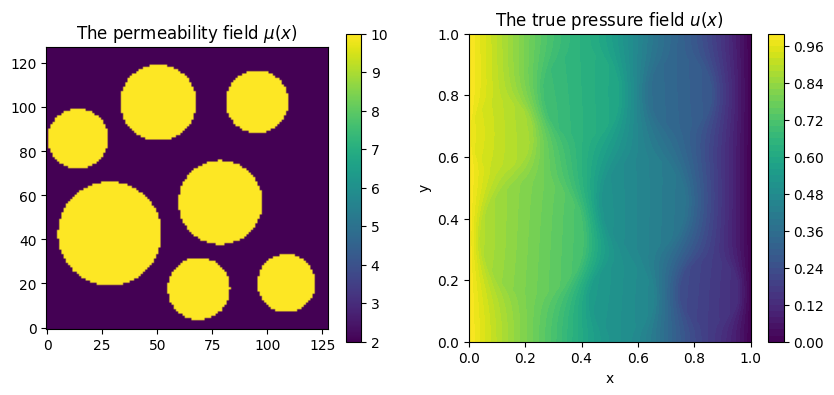

In [1]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

# ################################# The testing dataset
with h5py.File('ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

mu = fun_mu(x_test)

# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)
#
cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

In [1]:
#####  BASELINE DEFINITION #####

import h5py
import pathlib
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad, Variable
import matplotlib.pyplot as plt

np.random.seed(67)
torch.manual_seed(67)

DEVICE        = torch.device('cuda')
DATA_TYPE     = torch.float32
LEARNING_RATE = 0.001
EPOCHS        = 20000
W_PDE         = 1.0
LEFT_BOUND    = 0.0
U_LEFT_BOUND  = 1.0
RIGHT_BOUND   = 1.0
U_RIGHT_BOUND = 0.0
N_POINTS_BOUND= 10000
N_POINTS_INT  = 40000
LOWER_BOUND   = 0.0
UPPER_BOUND   = 1.0
MU_1          = 10.0
MU_2          = 2.0

DATA_PATH = 'ProblemB_dataset.h5'

with h5py.File(DATA_PATH, 'r') as file:
    mu_field  = np.array(file['mu_field']).reshape(-1, 1)
    x_test    = np.array(file['x_test']).reshape(-1, 2)
    u_test    = np.array(file['u_test']).reshape(-1, 1)

mu_field = torch.tensor(mu_field, dtype=DATA_TYPE, device=DEVICE)

x_test = torch.tensor(x_test, dtype=DATA_TYPE, device=DEVICE)
u_test = torch.tensor(u_test, dtype=DATA_TYPE, device=DEVICE)

def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

class MLP(nn.Module):
    
    def __init__(self, layers_list):
        super(MLP, self).__init__()
        self.activation = nn.Tanh()
        net = []
        self.hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=DATA_TYPE))
            self.hidden_in = hidden
        self.net = nn.Sequential(*net)
    
    def forward(self, x):
        h = x
        for net in self.net[:-1]:
            h = net(h)
            h = self.activation(h)
        raw = self.net[-1](h)

        xn = (x[:, 0:1] - LEFT_BOUND) / (RIGHT_BOUND - LEFT_BOUND)
        u = (1.0 - xn) * U_LEFT_BOUND + xn * U_RIGHT_BOUND + xn * (1.0 - xn) * raw

        return u

u_model = MLP([2, 64, 64, 64, 64, 64, 1]).to(DEVICE)

x_left = np.array(LEFT_BOUND).repeat(N_POINTS_BOUND, axis=0)
y_left = np.linspace(LOWER_BOUND, UPPER_BOUND, N_POINTS_BOUND).flatten()
xy_left = np.vstack([x_left, y_left]).T

x_right = np.array(RIGHT_BOUND).repeat(N_POINTS_BOUND, axis=0)
y_right = np.linspace(LOWER_BOUND, UPPER_BOUND, N_POINTS_BOUND).flatten()
xy_right = np.vstack([x_right, y_right]).T

xy_bd = np.vstack([xy_left, xy_right])
xy_bd = torch.tensor(xy_bd, dtype=DATA_TYPE, device=DEVICE)

u_bd = 1.0 - xy_bd[:, 0:1]

class LossClass(object):

    def __init__(self, u_model):
        self.device = DEVICE
        self.u_model = u_model 
        self.getLoss = torch.nn.MSELoss()
        
    def loss_pde(self, x_int=None):
        if x_int is None:
            x_int = np.random.uniform([LEFT_BOUND, LOWER_BOUND], [RIGHT_BOUND, UPPER_BOUND], (N_POINTS_INT, 2))
            x_int = torch.tensor(x_int, dtype=DATA_TYPE)

        xy = Variable(x_int, requires_grad=True).to(self.device)
        u = self.u_model(xy)
        
        du_dx = grad(inputs=xy, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        mu_x = fun_mu(xy.detach())

        energy = 0.5 * (mu_x * du_dx.pow(2).sum(dim=1, keepdim=True)).mean()
        
        return energy
    
    def get_error(self, x_test, u_test):
        x_test = x_test.to(self.device)
        u_test = u_test.to(self.device)
        u = self.u_model(x_test)
        
        return torch.sqrt(torch.sum((u-u_test)**2)/torch.sum(u_test**2))
    
OPTIMIZER = torch.optim.Adam(params=u_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
SCHEDULER = torch.optim.lr_scheduler.StepLR(OPTIMIZER, step_size=np.int32(EPOCHS/10), gamma=0.8)

In [2]:
#####  TRAINING LOOP #####

error_list = []
for epoch in range(EPOCHS):
    lossClass = LossClass(u_model)

    loss_in = lossClass.loss_pde(x_int=None)
    loss_train = W_PDE*loss_in

    OPTIMIZER.zero_grad()
    loss_train.backward()
    OPTIMIZER.step()

    with torch.no_grad():
        error = lossClass.get_error(x_test, u_test)
        error_list.append(error.item())

    SCHEDULER.step()
    if (epoch+1)%500==0:
        print(f'Epoch:{epoch}, The loss is:{loss_train.item()}, The L^2 Relative Error is: {error_list[-1]}, lr: {SCHEDULER.optimizer.param_groups[0]["lr"]}')

Epoch:499, The loss is:2.1741585731506348, The L^2 Relative Error is: 0.0701269879937172, lr: 0.001
Epoch:999, The loss is:1.9772542715072632, The L^2 Relative Error is: 0.0331391766667366, lr: 0.001
Epoch:1499, The loss is:1.880281925201416, The L^2 Relative Error is: 0.019946152344346046, lr: 0.001
Epoch:1999, The loss is:1.8591945171356201, The L^2 Relative Error is: 0.015550603158771992, lr: 0.0008
Epoch:2499, The loss is:1.8625907897949219, The L^2 Relative Error is: 0.016099220141768456, lr: 0.0008
Epoch:2999, The loss is:1.8235889673233032, The L^2 Relative Error is: 0.016238832846283913, lr: 0.0008
Epoch:3499, The loss is:1.8180100917816162, The L^2 Relative Error is: 0.009605564177036285, lr: 0.0008
Epoch:3999, The loss is:1.8267722129821777, The L^2 Relative Error is: 0.008868037723004818, lr: 0.00064
Epoch:4499, The loss is:1.8236424922943115, The L^2 Relative Error is: 0.019240714609622955, lr: 0.00064
Epoch:4999, The loss is:1.8206210136413574, The L^2 Relative Error is: 0

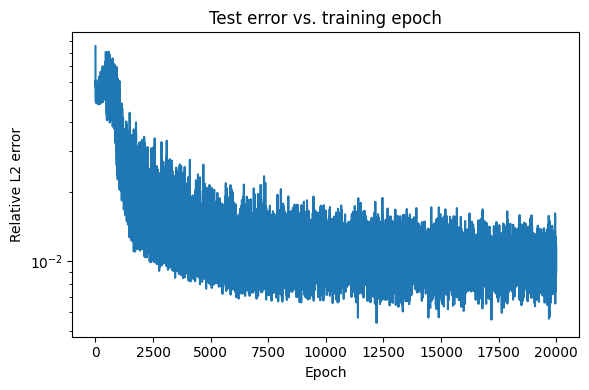

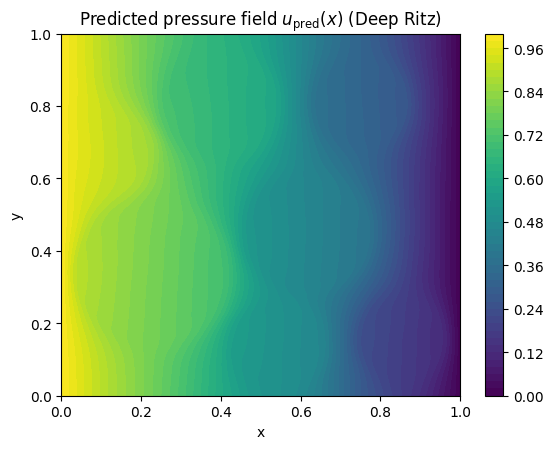

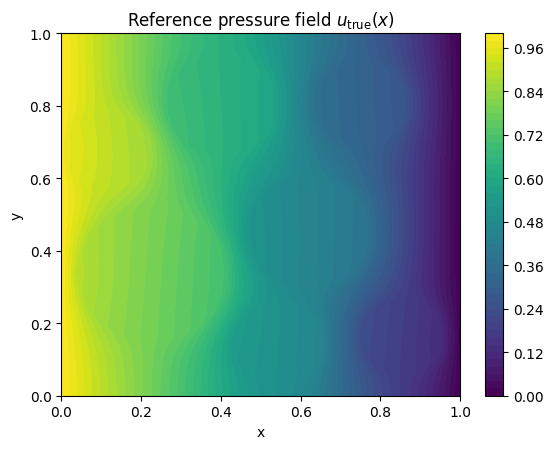

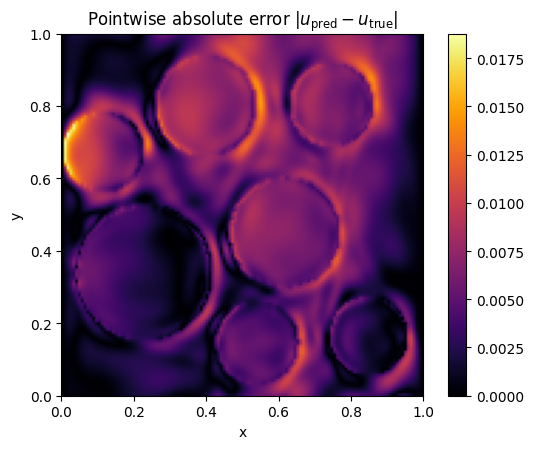

In [3]:
##### PLOTTING #####

plt.figure(figsize=(6, 4))
plt.semilogy(range(EPOCHS), error_list)
plt.xlabel('Epoch')
plt.ylabel('Relative L2 error')
plt.title('Test error vs. training epoch')
plt.tight_layout()
plt.show()

X = x_test[:, 0].reshape(128, 128).cpu()
Y = x_test[:, 1].reshape(128, 128).cpu()
u_test_grid = u_test.reshape(128, 128).cpu()

x_te      = x_test.to(DEVICE)
u_te      = u_test.reshape(-1, 1).to(DEVICE)
u_te_norm = torch.linalg.norm(u_te)

final_net = u_model

with torch.no_grad():
    U_pred = final_net(x_te).reshape(128, 128).cpu()

plt.figure(figsize=(5.8, 4.6))
cntr = plt.contourf(X, Y, U_pred, levels=50)
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title(r'Predicted pressure field $u_\mathrm{pred}(x)$ (Deep Ritz)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5.8, 4.6))
cntr = plt.contourf(X, Y, u_test_grid, levels=50)
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title(r'Reference pressure field $u_\mathrm{true}(x)$')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5.8, 4.6))
cntr = plt.imshow(torch.abs(U_pred - u_test_grid), origin='lower', extent=(0, 1, 0, 1), cmap='inferno')
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title(r'Pointwise absolute error $|u_\mathrm{pred} - u_\mathrm{true}|$')
plt.tight_layout(); plt.show()